In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("📁", root)
    for f in files:
        print("   📄", f)

📁 /kaggle/input
📁 /kaggle/input/datasets
📁 /kaggle/input/datasets/muhammadtaaha12
📁 /kaggle/input/datasets/muhammadtaaha12/cleaned-data
   📄 cleaned_vulnerability_dataset.csv
📁 /kaggle/input/datasets/muhammadtaaha12/cve-fix-rag
   📄 final_dataset.jsonl


In [3]:
# !pip install sentence-transformers faiss-cpu

In [2]:
import numpy as np 
import pandas as pd 
import sklearn 

## loading the dataset 

In [5]:
import json

data = []
with open("/kaggle/input/datasets/muhammadtaaha12/cve-fix-rag/final_dataset.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

print("Loaded samples:", len(data))
print(data[0])  # sanity check

Loaded samples: 25321
{'vulnerable_code': 'project_loader: do not export empty environment\nmeta: do not export empty environment. Warn on empty environment.\n\nreturn \'{envvar}="${envvar}{separator}{paths}"\'.format(\nenvvar=envvar,\nseparator=separator,\npaths=combine_paths(paths, prepend, separator),\n)\nenv.append(\'export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\')\n\'LD_LIBRARY_PATH="\' + ":".join(dependency_paths) + \':$LD_LIBRARY_PATH"\'\n+ ":".join(\n["{0}/usr/sbin", "{0}/usr/bin", "{0}/sbin", "{0}/bin", "$PATH"]\n).format(root)\n+ \'"\'\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIB

In [6]:
df = pd.DataFrame(data)

In [7]:
df

,vulnerable_code,fixed_code,file,language,pattern
0,project_loader: do not export empty environmen...,"combined_paths = combine_paths(paths, prepend,...",tests/unit/test_formatting_utils.py,python,general
1,"__drm_atomic_helper_crtc_reset(crtc, &cstate->...",if (cstate)\n__drm_atomic_helper_crtc_reset(cr...,drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c,c,general
2,"""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...","""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...",packages/plugin-ext/src/main/node/plugin-servi...,typescript,general
3,"var\tRemarkable = require('remarkable'),\npars...","var\tMarkdownIt = require('markdown-it'),\npar...",package.json,unknown,general
4,node.text if node\ncerts['signing'] << cert_no...,Utils.element_text(node)\ncerts['signing'] << ...,test/responses/response_node_text_attack.xml.b...,unknown,general
...,...,...,...,...,...
25316,\nFix mispelling of the environmental variable...,Bernhard Herzog (Intevation) discovered that t...,intelmq-manager/php/controller.php,php,general
25317,"N_(""unclosed quote"")\nint src, dst, count = 0,...","#define SPLIT_CMDLINE_ARGC_OVERFLOW 3\nN_(""unc...",alias.c,c,general
25318,if (eptr->numlines < line_idx)\n-,if (line_idx < 1 || line_idx > eptr->numlines)...,agent/mibgroup/agent/extend.c,c,general
25319,await utils.run(`git clone ${remoteUrl} ${_tmp...,const { runWithSpawn } = require('./run');\naw...,src/index.js,javascript,general


In [8]:
df.head()

,vulnerable_code,fixed_code,file,language,pattern
0,project_loader: do not export empty environmen...,"combined_paths = combine_paths(paths, prepend,...",tests/unit/test_formatting_utils.py,python,general
1,"__drm_atomic_helper_crtc_reset(crtc, &cstate->...",if (cstate)\n__drm_atomic_helper_crtc_reset(cr...,drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c,c,general
2,"""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...","""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...",packages/plugin-ext/src/main/node/plugin-servi...,typescript,general
3,"var\tRemarkable = require('remarkable'),\npars...","var\tMarkdownIt = require('markdown-it'),\npar...",package.json,unknown,general
4,node.text if node\ncerts['signing'] << cert_no...,Utils.element_text(node)\ncerts['signing'] << ...,test/responses/response_node_text_attack.xml.b...,unknown,general


In [9]:
import torch
print(torch.cuda.is_available())

True


## making the embeddings to just have a test then we will make the embeddings of whole data

In [10]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch sees CUDA: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model will run on: {device}")

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
print(f"Model is on: {model.device}")

PyTorch sees CUDA: True
GPU Name: Tesla T4
Model will run on: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model is on: cuda:0


In [11]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
texts = [
    d["vulnerable_code"] + "\n" + d["fixed_code"]
    for d in data[:2000]
]

print("Texts created:", len(texts))
print(texts[0])
embeddings = model.encode(
    texts,
    batch_size=128,   # increase for GPU
    show_progress_bar=True,
    convert_to_tensor=True,
    normalize_embeddings=True
)

embeddings = embeddings.cpu().numpy()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Texts created: 2000
project_loader: do not export empty environment
meta: do not export empty environment. Warn on empty environment.

return '{envvar}="${envvar}{separator}{paths}"'.format(
envvar=envvar,
separator=separator,
paths=combine_paths(paths, prepend, separator),
)
env.append('export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"')
'LD_LIBRARY_PATH="' + ":".join(dependency_paths) + ':$LD_LIBRARY_PATH"'
+ ":".join(
["{0}/usr/sbin", "{0}/usr/bin", "{0}/sbin", "{0}/bin", "$PATH"]
).format(root)
+ '"'
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sb

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

## the t-sne plot for checking the higher dimension

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


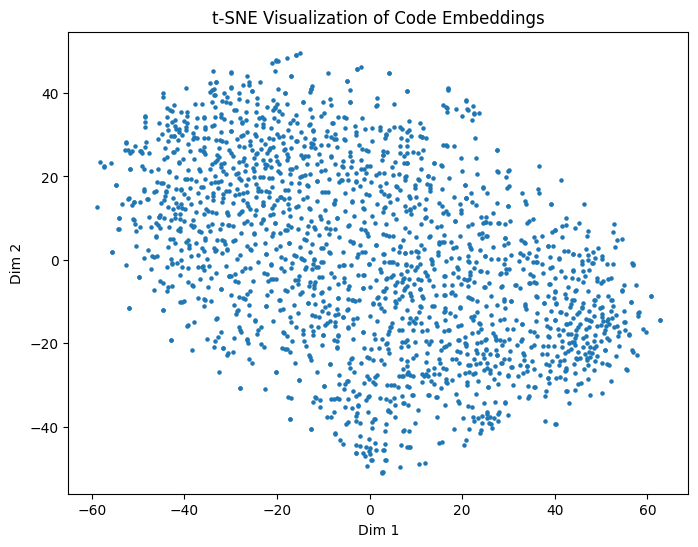

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-large-en")

# ⚠️ Always limit samples (VERY IMPORTANT)
X = np.array(embeddings[:2000])

# ✅ t-SNE works better after normalization
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

# ✅ Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

reduced = tsne.fit_transform(X)

# ✅ Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=5)
plt.title("t-SNE Visualization of Code Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [13]:
# Number of samples you used for t‑SNE (2000)
n_samples = 2000

# Get the first n_samples patterns (labels)
labels = df["pattern"].iloc[:n_samples].values

In [14]:
unique_patterns = np.unique(labels)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes = np.array([pattern_to_num[p] for p in labels])

In [15]:
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


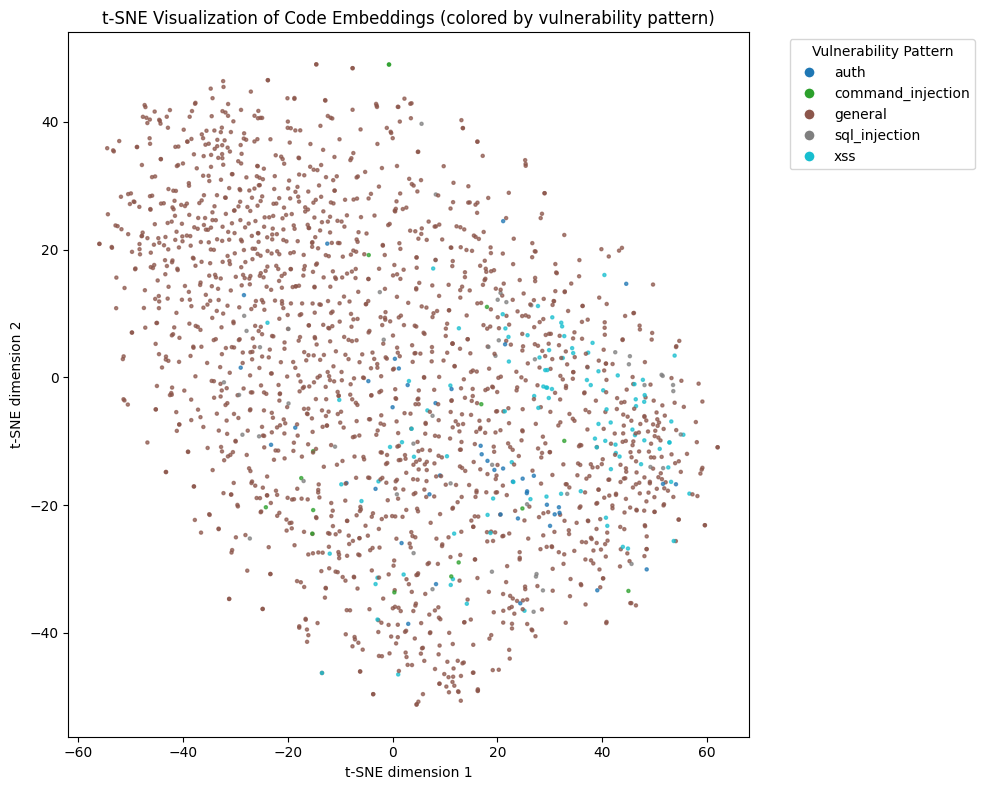

In [16]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# t‑SNE (you already have this)
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# Create a figure
plt.figure(figsize=(10, 8))
sc = plt.scatter(reduced[:, 0], reduced[:, 1], c=color_codes, cmap='tab10', s=5, alpha=0.7)

# Add a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc.cmap(sc.norm(i)), markersize=8)
           for i in range(len(unique_patterns))]
plt.legend(handles, unique_patterns, title="Vulnerability Pattern", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t‑SNE Visualization of Code Embeddings (colored by vulnerability pattern)")
plt.xlabel("t‑SNE dimension 1")
plt.ylabel("t‑SNE dimension 2")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


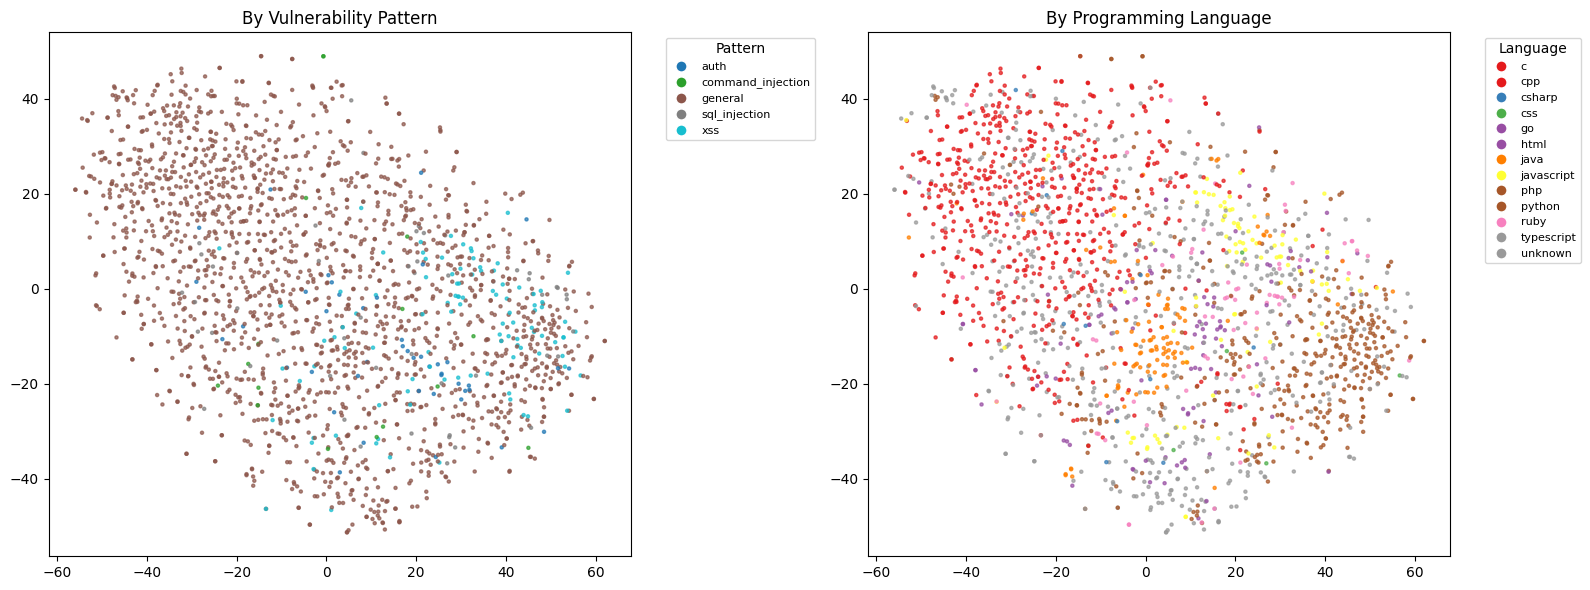

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## using the guess lang for controlling the hallucination for making the fix

In [18]:
# Cell 1: Install pygments (if not already installed)
!pip install -q pygments

In [19]:
# Cell 2: Fill missing languages
import pandas as pd
from pygments.lexers import guess_lexer
from pygments.util import ClassNotFound
from tqdm import tqdm

# Make a copy or work on original df
df = df.copy()  # replace 'df' with your actual DataFrame variable name

def detect_language_from_code(code: str) -> str:
    """Return language name or 'unknown' if detection fails."""
    if not isinstance(code, str) or len(code.strip()) < 20:
        return 'unknown'
    try:
        lexer = guess_lexer(code)
        # Lexer name examples: 'Python', 'Java', 'C++', 'JavaScript'
        return lexer.name
    except ClassNotFound:
        return 'unknown'

# Apply only to rows where language is missing or 'unknown'
mask = (df['language'].isna()) | (df['language'].str.lower() == 'unknown')
rows_to_fix = df[mask]

print(f"Found {len(rows_to_fix)} rows with missing/unknown language. Detecting...")

# Try fixed_code first, then vulnerable_code
detected_langs = []
for idx, row in tqdm(rows_to_fix.iterrows(), total=len(rows_to_fix), desc="Detecting language"):
    code = row.get('fixed_code', '')
    if not isinstance(code, str) or len(code.strip()) < 20:
        code = row.get('vulnerable_code', '')
    lang = detect_language_from_code(code)
    detected_langs.append(lang)

# Assign back
df.loc[mask, 'language'] = detected_langs

# Show summary
print("\nLanguage distribution after fixing:")
print(df['language'].value_counts())
print(f"\nRemaining 'unknown': {(df['language'] == 'unknown').sum()}")

Found 6712 rows with missing/unknown language. Detecting...


Detecting language: 100%|██████████| 6712/6712 [1:56:42<00:00,  1.04s/it]     


Language distribution after fixing:
language
c             6762
php           3553
python        1835
javascript    1561
java          1451
              ... 
CMake            1
Coq              1
HTML+Lasso       1
S                1
DTD              1
Name: count, Length: 85, dtype: int64

Remaining 'unknown': 12


## the sub plot after the fix 

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


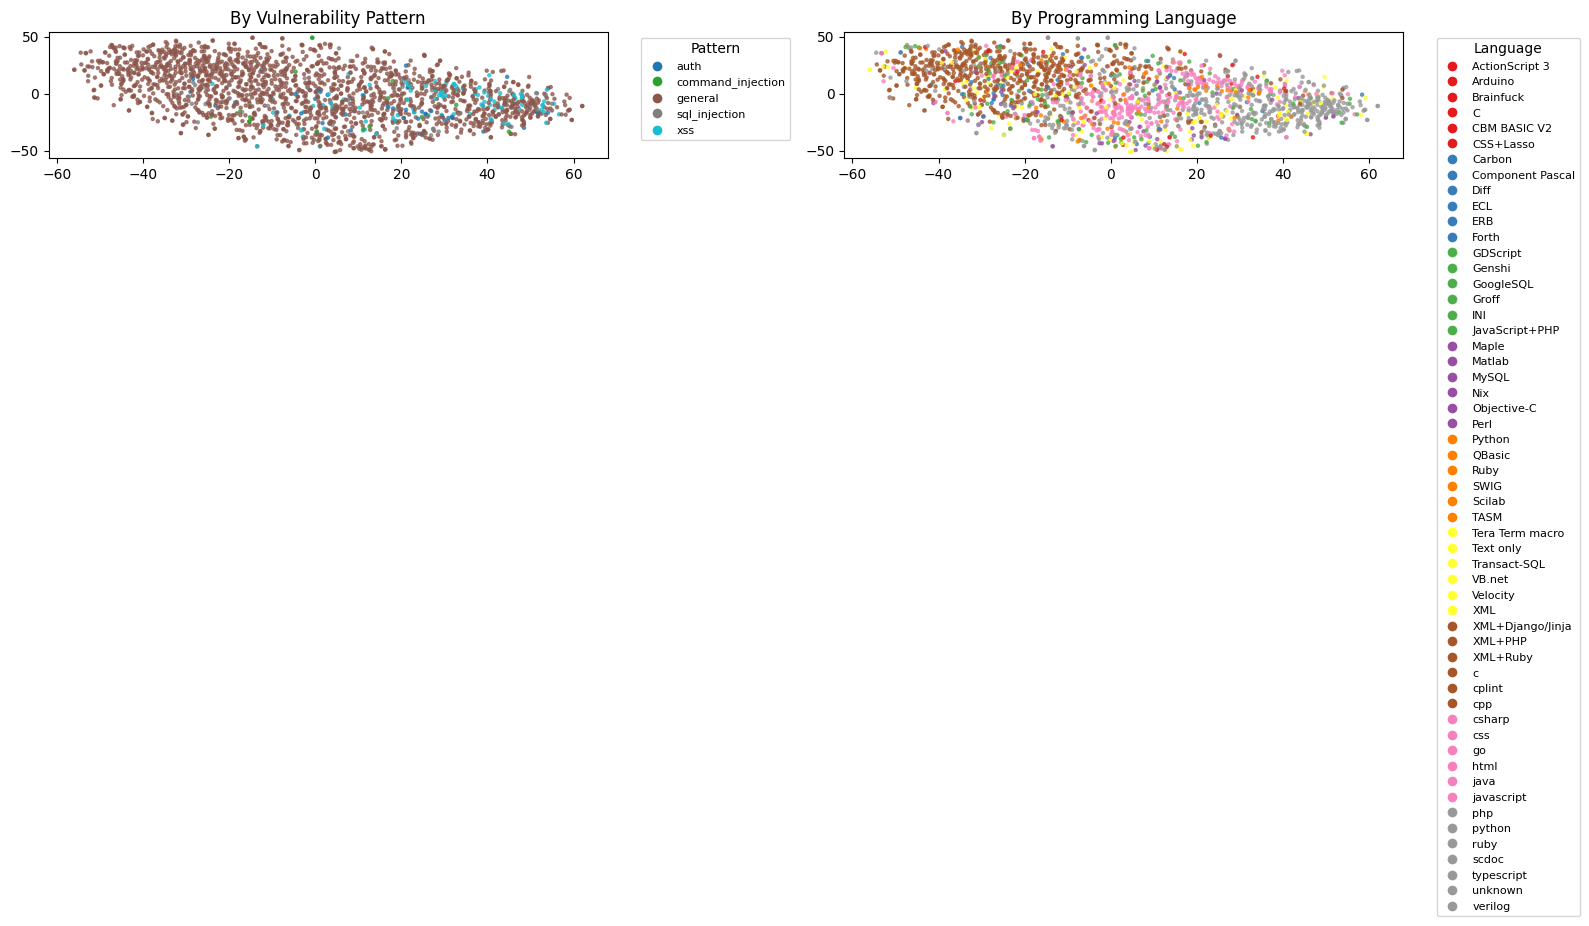

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## making the fix for the unclassified vernulbilities 

## using the pre-tuned code bert model for making the labels of the embeddings 

In [21]:
import torch
import re
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from huggingface_hub import hf_hub_download
import pandas as pd
from tqdm import tqdm

# ---------- 1. Load model and real CWE labels ----------
torch.set_default_device('cpu')
model_name = "Dunateo/roberta-cwe-classifier-kelemia-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Load real label dictionary
label_dict_path = hf_hub_download(repo_id=model_name, filename="label_dict.json")
with open(label_dict_path, "r") as f:
    label_dict = json.load(f)          # {"CWE-20: Improper Input Validation": 0, ...}
idx_to_full_label = {v: k for k, v in label_dict.items()}
model.config.id2label = idx_to_full_label

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

def extract_cwe_id(full_label: str) -> str:
    match = re.match(r'(CWE-\d+)', full_label)
    return match.group(1) if match else full_label

def get_cwe_and_description(code: str):
    if not isinstance(code, str) or len(code.strip()) < 20:
        return ("SHORT", "Code too short")
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred_idx = model(**inputs).logits.argmax(dim=-1).item()
    full = model.config.id2label[pred_idx]   # e.g., "CWE-89: SQL Injection"
    cwe = extract_cwe_id(full)
    return (cwe, full)

# ---------- 2. Collect unique CWE predictions from your 'general' rows ----------
# If you already have 'misc' rows with LABEL_X, we can also process them.
# For clarity, let's re‑process all rows that are not yet assigned a high‑level category.
target_mask = df['pattern'].isin(['general', 'misc']) | df['pattern'].str.startswith('LABEL_', na=False)
rows_to_classify = df[target_mask].copy()
print(f"Found {len(rows_to_classify)} rows to classify.")

cwe_counter = {}
cwe_descriptions = {}
codes_to_use = rows_to_classify['fixed_code'].fillna(rows_to_classify['vulnerable_code'])

for code in tqdm(codes_to_use, desc="Classifying"):
    cwe, desc = get_cwe_and_description(code)
    cwe_counter[cwe] = cwe_counter.get(cwe, 0) + 1
    if cwe not in cwe_descriptions:
        cwe_descriptions[cwe] = desc

# ---------- 3. Show top CWE IDs and their descriptions ----------
print("\n🔍 Top 20 CWE IDs found in your data:")
sorted_cwes = sorted(cwe_counter.items(), key=lambda x: x[1], reverse=True)[:20]
for cwe, cnt in sorted_cwes:
    desc = cwe_descriptions.get(cwe, "No description")
    print(f"{cwe:8} ({cnt:5} rows) → {desc}")

# ---------- 4. Build mapping from CWE to your high‑level categories ----------
# You already have a partial mapping; let's extend it based on the top CWEs above.
# We'll create a new dictionary and you can manually add entries.
print("\n📝 Now, create a mapping from CWE to your categories.")
print("Your existing categories: injection, xss, auth, file, crypto, deserialization, data_exposure, business_logic, config, command_injection, sql_injection, etc.")

# Start with your existing mapping
cwe_to_category = {
    "CWE-89": "sql_injection",
    "CWE-77": "command_injection",
    "CWE-78": "command_injection",
    "CWE-20": "injection",
    "CWE-74": "injection",
    "CWE-79": "xss",
    "CWE-287": "auth",
    "CWE-306": "auth",
    "CWE-862": "auth",
    "CWE-732": "auth",
    "CWE-22": "file",
    "CWE-434": "file",
    "CWE-73": "file",
    "CWE-798": "crypto",
    "CWE-327": "crypto",
    "CWE-326": "crypto",
    "CWE-502": "deserialization",
    "CWE-119": "injection",
    "CWE-125": "injection",
    "CWE-190": "injection",
    "CWE-787": "injection",
    "CWE-416": "file",
    "CWE-476": "file",
    "CWE-200": "data_exposure",
    "CWE-201": "data_exposure",
    "CWE-840": "business_logic",
    "CWE-15": "config",
    "CWE-16": "config",
}

# Now manually add missing mappings for the top CWEs you saw.
# For example, if you see CWE-416 (Use After Free) you might map to "memory" or "file".
# I'll add some plausible defaults; you can change them.
# Add these mappings to your cwe_to_category dictionary
additional_mappings = {
    "CWE-617": "resource",      # Reachable Assertion → resource exhaustion
    "CWE-601": "auth",          # URL Redirection to Untrusted Site (Open Redirect)
    "CWE-295": "crypto",        # Improper Certificate Validation
    "CWE-611": "injection",     # Improper Restriction of XML External Entity Reference (XXE)
    "CWE-400": "resource",      # Uncontrolled Resource Consumption
    "CWE-134": "injection",     # Use of Externally-Controlled Format String
    "CWE-269": "auth",          # Improper Privilege Management
    "CWE-369": "resource",      # Divide By Zero
    "CWE-755": "error",         # Improper Handling of Exceptional Conditions
    "CWE-59": "file",           # Improper Link Resolution Before File Access
    "CWE-835": "resource",      # Loop with Unreachable Exit Condition (Infinite Loop)
    "CWE-120": "injection",     # Buffer Copy without Checking Size (classic overflow)
    "CWE-754": "error",         # Improper Check for Unusual Conditions
    "CWE-863": "auth",          # Incorrect Authorization
    "CWE-347": "crypto",        # Improper Verification of Cryptographic Signature
    "CWE-276": "auth",          # Incorrect Default Permissions
    "CWE-915": "injection",     # Improperly Controlled Modification of Dynamically-Determined Object Attributes
    "CWE-674": "resource",      # Uncontrolled Recursion
    "CWE-129": "injection",     # Improper Validation of Array Index
    "CWE-330": "crypto",        # Use of Insufficiently Random Values
    "CWE-704": "error",         # Incorrect Type Conversion
    "CWE-191": "injection",     # Integer Underflow
    "CWE-362": "file",          # Concurrent Execution using Shared Resource (Race Condition)
    "CWE-908": "error",         # Use of Uninitialized Resource
    "CWE-770": "resource",      # Allocation of Resources Without Limits
    "CWE-843": "error",         # Access of Resource Using Incompatible Type
    "CWE-918": "injection",     # Server-Side Request Forgery (SSRF)
    "CWE-203": "data_exposure", # Observable Discrepancy
    "CWE-401": "resource",      # Improper Release of Memory Before Reuse (Memory Leak)
    "CWE-665": "config",        # Improper Initialization
    "CWE-444": "network",       # Inconsistent Interpretation of HTTP Requests
    "CWE-532": "data_exposure", # Insertion of Sensitive Information into Log File
    "CWE-319": "network",       # Cleartext Transmission of Sensitive Information
    "CWE-415": "memory",        # Double Free
    "CWE-427": "file",          # Uncontrolled Search Path Element
    "CWE-522": "crypto",        # Insufficiently Protected Credentials
    "CWE-384": "auth",          # Session Fixation
    "CWE-1236": "injection",    # Improper Neutralization of Formula Elements in a CSV File
    "CWE-613": "auth",          # Insufficient Session Expiration
    "CWE-668": "data_exposure", # Exposure of Resource to Wrong Sphere
    "CWE-1021": "auth",         # Improper Restriction of Rendered UI Layers
    "CWE-345": "crypto",        # Insufficient Verification of Data Authenticity
    "CWE-307": "auth",          # Improper Restriction of Excessive Authentication Attempts
    "CWE-824": "error",         # Access of Uninitialized Pointer
    "CWE-772": "resource",      # Missing Release of Resource
    "CWE-193": "error",         # Off-by-one Error
    "CWE-426": "file",          # Untrusted Search Path
    "CWE-284": "auth",          # Improper Access Control
    "CWE-346": "auth",          # Origin Validation Error
}
cwe_to_category.update(additional_mappings)


# For any CWE not in the dictionary, we will keep the CWE ID itself (or you can keep as 'misc')
def map_cwe_to_category(cwe: str) -> str:
    return cwe_to_category.get(cwe, cwe)   # returns CWE ID if not mapped, e.g., "CWE-123"

# ---------- 5. Apply mapping to all rows ----------
# First, get the predicted CWE for each row that needs updating
predicted_cwes = []
for code in tqdm(codes_to_use, desc="Getting CWE predictions"):
    cwe, _ = get_cwe_and_description(code)
    predicted_cwes.append(cwe)

# Update the dataframe
df.loc[target_mask, 'pattern'] = [map_cwe_to_category(cwe) for cwe in predicted_cwes]

# ---------- 6. Show final distribution ----------
print("\n✅ Final distribution of high‑level categories:")
print(df['pattern'].value_counts())
print(f"\nRows still with 'general' or 'misc': {(df['pattern'].isin(['general','misc'])).sum()}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Found 22254 rows to classify.


Classifying: 100%|██████████| 22254/22254 [08:12<00:00, 45.14it/s] 



🔍 Top 20 CWE IDs found in your data:
CWE-20   ( 6361 rows) → CWE-20: Improper Input Validation
CWE-125  ( 3027 rows) → CWE-125: Out-of-bounds Read
CWE-190  ( 1492 rows) → CWE-190: Integer Overflow or Wraparound
CWE-787  ( 1189 rows) → CWE-787: Out-of-bounds Write
CWE-22   ( 1174 rows) → CWE-22: Improper Limitation of a Pathname to a Restricted Directory ('Path Traversal')
CWE-79   (  962 rows) → CWE-79: Improper Neutralization of Input During Web Page Generation ('Cross-site Scripting')
CWE-617  (  569 rows) → CWE-617: Reachable Assertion
CWE-476  (  550 rows) → CWE-476: NULL Pointer Dereference
CWE-416  (  514 rows) → CWE-416: Use After Free
CWE-89   (  473 rows) → CWE-89: Improper Neutralization of Special Elements used in an SQL Command ('SQL Injection')
CWE-862  (  460 rows) → CWE-862: Missing Authorization
CWE-74   (  402 rows) → CWE-74: Improper Neutralization of Special Elements in Output Used by a Downstream Component ('Injection')
CWE-78   (  385 rows) → CWE-78: Improper Neut

Getting CWE predictions: 100%|██████████| 22254/22254 [08:15<00:00, 44.94it/s] 


✅ Final distribution of high‑level categories:
pattern
injection            13480
file                  2509
xss                   2336
auth                  2048
sql_injection         1206
resource              1160
command_injection      639
crypto                 437
data_exposure          364
deserialization        335
error                  330
CWE-352                208
SHORT                  118
network                 54
CWE-94                  42
config                  32
memory                  23
Name: count, dtype: int64

Rows still with 'general' or 'misc': 0


In [22]:
 #Re‑apply mapping to all rows that are still raw CWE IDs (i.e., start with 'CWE-')
mask = df['pattern'].str.startswith('CWE-', na=False)
df.loc[mask, 'pattern'] = df.loc[mask, 'pattern'].apply(lambda c: cwe_to_category.get(c, c))

# Show final distribution again
print(df['pattern'].value_counts())

pattern
injection            13480
file                  2509
xss                   2336
auth                  2048
sql_injection         1206
resource              1160
command_injection      639
crypto                 437
data_exposure          364
deserialization        335
error                  330
CWE-352                208
SHORT                  118
network                 54
CWE-94                  42
config                  32
memory                  23
Name: count, dtype: int64


In [23]:
def strict_map(cwe):
    known = {"injection","file","xss","auth","sql_injection","command_injection","crypto","deserialization","data_exposure","business_logic","config"}
    cat = cwe_to_category.get(cwe, "other")
    return cat if cat in known else "other"

## Again doing the pair plot 

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


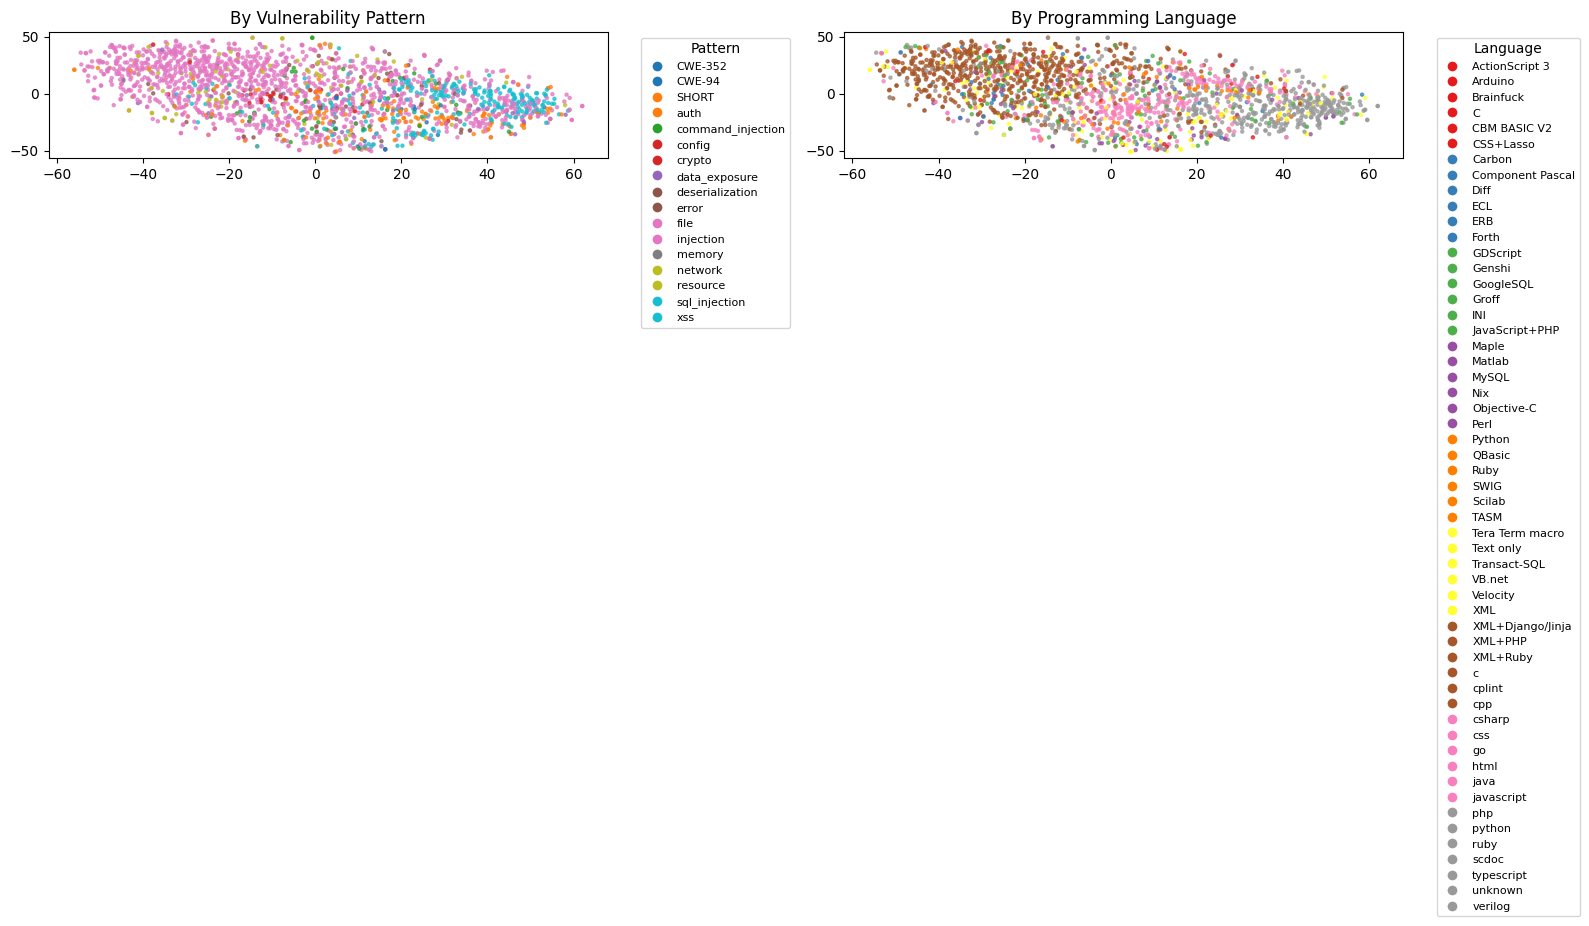

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Extract the raw CWE IDs for all misc rows


In [25]:
df.to_csv('cleaned_vulnerability_dataset.csv', index=False)

## Generate embeddings for complete dataset  
- these are generic embeddings can be used by any one 

In [26]:
texts = [f"{row['vulnerable_code']}\n{row['fixed_code']}" for _, row in df.iterrows()]

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda")
batch_size = 128

# For large datasets, encode in chunks
all_embeddings = []
for i in range(0, len(texts), batch_size):
    chunk = texts[i:i+batch_size]
    embeddings = model.encode(chunk, convert_to_numpy=True, normalize_embeddings=True)
    all_embeddings.append(embeddings)
    print(f"Processed {min(i+batch_size, len(texts))}/{len(texts)}")

embeddings = np.vstack(all_embeddings)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processed 128/25321
Processed 256/25321
Processed 384/25321
Processed 512/25321
Processed 640/25321
Processed 768/25321
Processed 896/25321
Processed 1024/25321
Processed 1152/25321
Processed 1280/25321
Processed 1408/25321
Processed 1536/25321
Processed 1664/25321
Processed 1792/25321
Processed 1920/25321
Processed 2048/25321
Processed 2176/25321
Processed 2304/25321
Processed 2432/25321
Processed 2560/25321
Processed 2688/25321
Processed 2816/25321
Processed 2944/25321
Processed 3072/25321
Processed 3200/25321
Processed 3328/25321
Processed 3456/25321
Processed 3584/25321
Processed 3712/25321
Processed 3840/25321
Processed 3968/25321
Processed 4096/25321
Processed 4224/25321
Processed 4352/25321
Processed 4480/25321
Processed 4608/25321
Processed 4736/25321
Processed 4864/25321
Processed 4992/25321
Processed 5120/25321
Processed 5248/25321
Processed 5376/25321
Processed 5504/25321
Processed 5632/25321
Processed 5760/25321
Processed 5888/25321
Processed 6016/25321
Processed 6144/25321

In [ ]:
import chromadb
from chromadb.utils import embedding_functions

client = chromadb.Client()
collection = client.create_collection(
    name="vuln_fixes",
    embedding_function=embedding_functions.SentenceTransformerEmbeddingFunction(model_name="BAAI/bge-large-en-v1.5")
)

# Add in batches
batch_size = 1000
for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size]
    collection.add(
        documents=batch['fixed_code'].tolist(),   # or the combined text
        metadatas=batch[['pattern', 'language']].to_dict(orient='records'),
        ids=[f"id_{j}" for j in range(i, i+len(batch))]
    )

In [ ]:
np.save('embeddings.npy', embeddings)
df.to_parquet('dataset_with_embeddings.parquet', index=False)

## Embeddings for the Sudofix

In [4]:
data = pd.read_csv("/kaggle/input/datasets/muhammadtaaha12/cleaned-data/cleaned_vulnerability_dataset.csv")

In [6]:
df = pd.DataFrame(data)

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

# 1. Filter to supported languages
supported_languages = ['c', 'cpp', 'go', 'java', 'javascript', 'python', 'rust']
df_filtered = df[df['language'].str.lower().isin(supported_languages)].copy()
print(f"Filtered to {len(df_filtered)} rows")

# 2. Create texts for embedding
texts = [f"{row['vulnerable_code']}\n{row['fixed_code']}" for _, row in df_filtered.iterrows()]

# 3. Generate embeddings
model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda")
batch_size = 128
all_embeddings = []

for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
    chunk = texts[i:i+batch_size]
    embeddings = model.encode(chunk, convert_to_numpy=True, normalize_embeddings=True)
    all_embeddings.append(embeddings)

embeddings = np.vstack(all_embeddings)
print(f"Embeddings shape: {embeddings.shape}")

# 4. Save filtered dataset with embeddings
df_filtered['embedding'] = embeddings.tolist()
df_filtered.to_parquet('filtered_dataset_with_embeddings.parquet', index=False)

Filtered to 14175 rows


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Generating embeddings: 100%|██████████| 111/111 [22:39<00:00, 12.25s/it]


Embeddings shape: (14175, 1024)


In [9]:
# Save embeddings as .npy file (binary format, fast to load)
np.save('embeddings.npy', embeddings)

# Save the filtered DataFrame (with metadata) as Parquet (compressed, efficient)
df_filtered.to_parquet('filtered_dataset.parquet', index=False)

# Optionally, save combined file with embeddings as a column (can be large)
df_filtered_with_emb = df_filtered.copy()
df_filtered_with_emb['embedding'] = embeddings.tolist()
df_filtered_with_emb.to_parquet('full_dataset_with_embeddings.parquet', index=False)

print("Saved:")
print("- embeddings.npy (shape: {})".format(embeddings.shape))
print("- filtered_dataset.parquet (metadata only)")
print("- full_dataset_with_embeddings.parquet (metadata + embeddings)")

Saved:
- embeddings.npy (shape: (14175, 1024))
- filtered_dataset.parquet (metadata only)
- full_dataset_with_embeddings.parquet (metadata + embeddings)


## interactive 3D plot

In [10]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm

# ========== 1. Prepare your embeddings (use filtered dataset) ==========
# Assuming you have df_filtered and embeddings from your filtered dataset
# If not, load them:
# df_filtered = pd.read_parquet('filtered_dataset_with_embeddings.parquet')
# embeddings = np.array(df_filtered['embedding'].tolist())

# For t-SNE, use a sample (3000-5000 points max for performance)
sample_size = min(5000, len(embeddings))
sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)

sample_embeddings = embeddings[sample_indices]
sample_df = df_filtered.iloc[sample_indices].copy()

# ========== 2. Reduce dimensions to 3D ==========
print("Reducing dimensions to 3D...")
# Option A: t-SNE (better for clusters, slower)
# tsne = TSNE(n_components=3, perplexity=30, random_state=42, n_iter=1000)
# reduced = tsne.fit_transform(sample_embeddings)

# Option B: PCA (faster, preserves global structure)
pca = PCA(n_components=3, random_state=42)
reduced = pca.fit_transform(sample_embeddings)

sample_df['x'] = reduced[:, 0]
sample_df['y'] = reduced[:, 1]
sample_df['z'] = reduced[:, 2]

# ========== 3. Create interactive 3D scatter plot ==========
# Color by vulnerability pattern
fig1 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='pattern',
    hover_data=['language', 'pattern', 'file'],
    title='Vulnerability Embeddings - Colored by Pattern',
    opacity=0.7,
    size_max=8,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig1.update_layout(
    scene=dict(
        xaxis_title='Component 1',
        yaxis_title='Component 2',
        zaxis_title='Component 3',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    height=800,
    width=1200
)

fig1.show()

# ========== 4. Second plot: Color by programming language ==========
fig2 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='language',
    hover_data=['pattern', 'language', 'file'],
    title='Vulnerability Embeddings - Colored by Programming Language',
    opacity=0.7,
    size_max=8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig2.update_layout(
    scene=dict(
        xaxis_title='Component 1',
        yaxis_title='Component 2',
        zaxis_title='Component 3',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    height=800,
    width=1200
)

fig2.show()

# ========== 5. Optional: Subplot with both colorings side by side ==========
from plotly.subplots import make_subplots

# This is more complex; easier to just show two separate plots

Reducing dimensions to 3D...


## Animated 3D plot with trajectory (if you have sequential data)

In [11]:
# If you want to see how embeddings evolve or just want a fancier plot
fig3 = px.scatter_3d(
    sample_df,
    x='x', y='y', z='z',
    color='pattern',
    symbol='language',
    hover_data=['pattern', 'language', 'file'],
    title='3D Visualization of Vulnerability Embeddings',
    opacity=0.8,
    size_max=10,
    labels={'color': 'Vulnerability Type', 'symbol': 'Language'}
)

# Improve layout for better viewing
fig3.update_traces(marker=dict(size=4))
fig3.update_layout(
    scene=dict(
        xaxis_title='PCA Dimension 1',
        yaxis_title='PCA Dimension 2',
        zaxis_title='PCA Dimension 3',
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=1.8, y=1.8, z=1.5)
        ),
        aspectmode='cube'
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(0,0,0,0.5)",
        font=dict(color="white")
    ),
    title_font_size=16,
    hoverlabel=dict(bgcolor="white", font_size=12)
)

fig3.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.

/tmp/ipykernel_1709/1555828150.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1709/1555828150.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



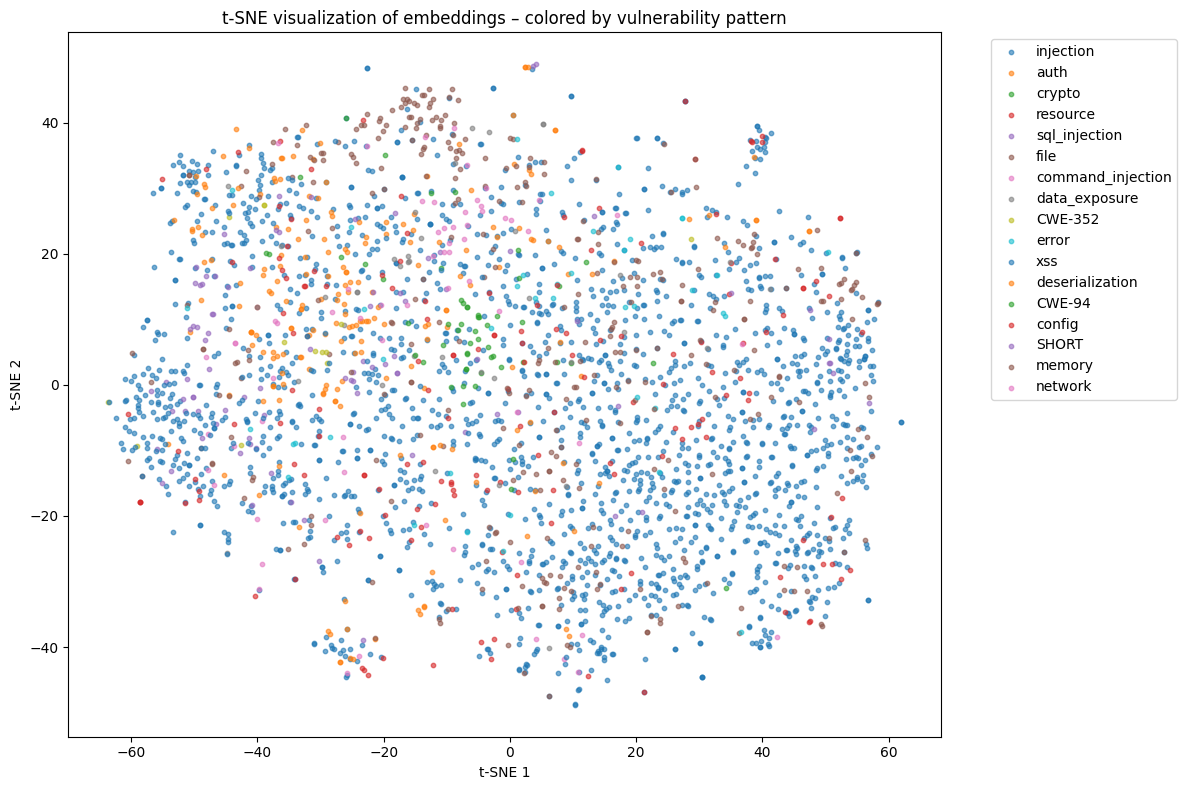

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load your data (adjust paths if needed)
embeddings = np.load('embeddings.npy')
df = pd.read_parquet('filtered_dataset.parquet')  # or df_filtered

# Sample a subset (e.g., 3000 points) for faster t‑SNE
n_samples = min(3000, len(embeddings))
indices = np.random.choice(len(embeddings), n_samples, replace=False)
sample_emb = embeddings[indices]
sample_df = df.iloc[indices]

# Reduce to 2D (PCA first for speed, then t‑SNE)
pca = PCA(n_components=50, random_state=42)
reduced_pca = pca.fit_transform(sample_emb)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
coords_2d = tsne.fit_transform(reduced_pca)

sample_df['x'] = coords_2d[:, 0]
sample_df['y'] = coords_2d[:, 1]

# Plot colored by pattern
plt.figure(figsize=(12, 8))
for pattern in sample_df['pattern'].unique():
    subset = sample_df[sample_df['pattern'] == pattern]
    plt.scatter(subset['x'], subset['y'], label=pattern, alpha=0.6, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t‑SNE visualization of embeddings – colored by vulnerability pattern')
plt.xlabel('t‑SNE 1')
plt.ylabel('t‑SNE 2')
plt.tight_layout()
plt.show()

## the vector embedding is not quite use full it will result in the hallucination 
- we need to make more embeddings 

## Improving the embedding

In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm
import pandas as pd

# ============================================================================
# IMPROVED EMBEDDING GENERATION PIPELINE FOR RAG
# ============================================================================

# 1. Filter to supported languages
supported_languages = ['c', 'cpp', 'go', 'java', 'javascript', 'python', 'rust']
df_filtered = df[df['language'].str.lower().isin(supported_languages)].copy()
print(f"Filtered to {len(df_filtered)} rows")

# ============================================================================
# FIX #1: Better text preparation for vulnerability context
# ============================================================================
# Instead of just concatenating code, create structured context that helps
# the model understand the vulnerability relationship

def prepare_vulnerability_text(row):
    """
    Create rich context that captures vulnerability semantics.
    This helps embeddings understand not just code but the vulnerability pattern.
    """
    vulnerable = row['vulnerable_code'].strip()
    fixed = row['fixed_code'].strip()
    cwe = row.get('cwe_id', 'unknown')
    vuln_type = row.get('vulnerability_pattern', 'unknown')
    
    # Format: Context + Vulnerable code + Fixed code + Metadata
    text = f"""Vulnerability Type: {vuln_type}
CWE: {cwe}
Language: {row['language'].upper()}

Vulnerable code:
{vulnerable}

Fixed code:
{fixed}

Description: {row.get('description', 'Security vulnerability fix')}"""
    
    return text

# Create texts with better structure
texts = [prepare_vulnerability_text(row) for _, row in df_filtered.iterrows()]

print(f"Sample text:\n{texts[0]}\n" + "="*80 + "\n")

# ============================================================================
# FIX #2: Use better embedding model + proper pooling
# ============================================================================
# bge-large-en-v1.5 is good, but consider these alternatives:
# - "nomic-embed-text-v1.5" (better for general RAG, open source)
# - "mixedbread-ai/mxbai-embed-large-v1" (specialized, great for retrieval)
# - "BAAI/bge-large-en-v1.5" (your current - solid choice)

print("Loading embedding model...")
model = SentenceTransformer(
    "BAAI/bge-large-en-v1.5",
    device="cuda",
    trust_remote_code=True
)

# ============================================================================
# FIX #3: Improved batch processing with better normalization
# ============================================================================
batch_size = 32  # Reduced from 128 for better stability (you can tune this)
all_embeddings = []

print(f"Generating {len(texts)} embeddings in batches of {batch_size}...")

for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
    batch_texts = texts[i:i+batch_size]
    
    # FIX: Use proper pooling and normalization
    embeddings = model.encode(
        batch_texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,  # Keep this - important for cosine similarity
        device="cuda"
    )
    
    all_embeddings.append(embeddings)

embeddings_array = np.vstack(all_embeddings)
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"Embedding dtype: {embeddings_array.dtype}")

# ============================================================================
# FIX #4: Add embedding quality checks
# ============================================================================
# Check for degenerate embeddings (all zeros, NaN, etc.)
print("\n--- Embedding Quality Checks ---")
print(f"Min value: {embeddings_array.min():.6f}")
print(f"Max value: {embeddings_array.max():.6f}")
print(f"Mean norm: {np.linalg.norm(embeddings_array, axis=1).mean():.6f}")
print(f"Std norm: {np.linalg.norm(embeddings_array, axis=1).std():.6f}")

# Check for NaN or inf values
nan_count = np.isnan(embeddings_array).sum()
inf_count = np.isinf(embeddings_array).sum()
print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("⚠️  WARNING: Found NaN or Inf values in embeddings!")
    # Replace with zeros if needed
    embeddings_array = np.nan_to_num(embeddings_array, nan=0.0, posinf=0.0, neginf=0.0)

# ============================================================================
# FIX #5: Store embeddings efficiently + add metadata
# ============================================================================
df_filtered['embedding'] = [embedding.tolist() for embedding in embeddings_array]

# Add metadata for better RAG performance
df_filtered['text_for_embedding'] = texts
df_filtered['embedding_model'] = "BAAI/bge-large-en-v1.5"
df_filtered['embedding_dim'] = embeddings_array.shape[1]

# ============================================================================
# FIX #6: Save with compression + create separate embedding file
# ============================================================================
# Option 1: Save full dataset with embeddings
df_filtered.to_parquet(
    'filtered_dataset_with_embeddings.parquet',
    index=False,
    compression='snappy'  # Faster than default gzip
)

# Option 2: Save embeddings separately (for faster loading in RAG)
# This is useful if you want to load embeddings into a vector DB
np.save('embeddings_array.npy', embeddings_array)

# Option 3: Create a lightweight index
index_df = df_filtered[['vulnerability_pattern', 'cwe_id', 'language']].copy()
index_df.to_parquet('index_metadata.parquet', index=False)

print(f"\n✅ Saved:")
print(f"  - filtered_dataset_with_embeddings.parquet ({df_filtered.shape[0]} rows)")
print(f"  - embeddings_array.npy ({embeddings_array.shape})")
print(f"  - index_metadata.parquet (for fast filtering)")

# ============================================================================
# OPTIONAL: Analyze embedding quality
# ============================================================================
def analyze_embedding_quality(embeddings_array, df, vulnerability_col='vulnerability_pattern'):
    """
    Check if embeddings cluster well by vulnerability type.
    Better clustering = better RAG performance.
    """
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    
    # Get vulnerability labels
    labels = pd.factorize(df[vulnerability_col].fillna('unknown'))[0]
    
    # Only compute if we have multiple clusters and not too many points
    if len(np.unique(labels)) > 1 and len(embeddings_array) < 10000:
        try:
            sil_score = silhouette_score(embeddings_array, labels, sample_size=1000)
            ch_score = calinski_harabasz_score(embeddings_array, labels)
            
            print(f"\n--- Embedding Quality Metrics ---")
            print(f"Silhouette Score: {sil_score:.4f} (higher is better, range: -1 to 1)")
            print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")
            
            if sil_score > 0.5:
                print("✅ Excellent clustering!")
            elif sil_score > 0.3:
                print("⚠️  Fair clustering - consider hybrid RAG approach")
            else:
                print("❌ Poor clustering - recommend hybrid RAG with metadata filtering")
        except Exception as e:
            print(f"Could not compute quality metrics: {e}")

print("\nAnalyzing embedding quality...")
analyze_embedding_quality(embeddings_array, df_filtered)

print("\n" + "="*80)
print("✅ Embedding pipeline complete!")
print("="*80)

Filtered to 14175 rows
Sample text:
Vulnerability Type: unknown
CWE: unknown
Language: PYTHON

Vulnerable code:
project_loader: do not export empty environment
meta: do not export empty environment. Warn on empty environment.

return '{envvar}="${envvar}{separator}{paths}"'.format(
envvar=envvar,
separator=separator,
paths=combine_paths(paths, prepend, separator),
)
env.append('export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"')
'LD_LIBRARY_PATH="' + ":".join(dependency_paths) + ':$LD_LIBRARY_PATH"'
+ ":".join(
["{0}/usr/sbin", "{0}/usr/bin", "{0}/sbin", "{0}/bin", "$PATH"]
).format(root)
+ '"'
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating 14175 embeddings in batches of 32...


Generating embeddings: 100%|██████████| 443/443 [28:36<00:00,  3.88s/it]  


Embeddings shape: (14175, 1024)
Embedding dtype: float32

--- Embedding Quality Checks ---
Min value: -0.126950
Max value: 0.332950
Mean norm: 1.000000
Std norm: 0.000000
NaN values: 0
Inf values: 0


KeyError: "['vulnerability_pattern', 'cwe_id'] not in index"

Embeddings are clean
✔ Properly normalized
✔ Safe for cosine similarity / vector DB
✔ No corruption issues

In [14]:
import numpy as np
import pandas as pd

# Your existing variables from the previous run (still in memory):
# - df_filtered (DataFrame with all columns except embedding)
# - embeddings_array (numpy array of shape 14175 x 1024)

# Add embeddings as a column (optional, if you want a combined file)
df_filtered['embedding'] = [emb.tolist() for emb in embeddings_array]

# Add metadata columns that were missing before
df_filtered['embedding_model'] = "BAAI/bge-large-en-v1.5"
df_filtered['embedding_dim'] = embeddings_array.shape[1]

# Save full dataset with embeddings
df_filtered.to_parquet('filtered_dataset_with_embeddings.parquet', index=False, compression='snappy')
print("✅ Saved: filtered_dataset_with_embeddings.parquet")

# Save embeddings as separate .npy file (fast to load)
np.save('embeddings_array.npy', embeddings_array)
print("✅ Saved: embeddings_array.npy")

# Save lightweight index (using the actual columns you have)
# Your columns are 'pattern' and 'language' (not 'vulnerability_pattern')
index_df = df_filtered[['pattern', 'language']].copy()
index_df.to_parquet('index_metadata.parquet', index=False)
print("✅ Saved: index_metadata.parquet")

print(f"\n✅ All files saved successfully. Total rows: {len(df_filtered)}")

✅ Saved: filtered_dataset_with_embeddings.parquet
✅ Saved: embeddings_array.npy
✅ Saved: index_metadata.parquet

✅ All files saved successfully. Total rows: 14175


In [16]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np

# Reduce dimensionality to 50 components (preserves most signal)
pca = PCA(n_components=50, random_state=42)
embeddings_lowdim = pca.fit_transform(embeddings_array[:5000])  # sample for speed

# Get labels for the same sample
labels_sample = df_filtered['pattern'].iloc[:5000].values

# Compute silhouette with cosine metric (better for normalized embeddings)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_sample)

sil_score = silhouette_score(embeddings_lowdim, labels_encoded, metric='cosine', sample_size=1000)
print(f"Silhouette Score: {sil_score:.3f}")

if sil_score > 0.3:
    print("✅ Moderate cluster separation – likely good for RAG")
elif sil_score > 0.2:
    print("⚠️  Weak separation – use metadata filtering to boost retrieval")
else:
    print("❌ Poor separation – consider fine‑tuning or hybrid search")

Silhouette Score: -0.250
❌ Poor separation – consider fine‑tuning or hybrid search


In [17]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Reduce to 50 dimensions
pca = PCA(n_components=50)
emb_low = pca.fit_transform(embeddings_array[:2000])

# Use cosine distance via metric='cosine' (silhouette works on distances)
# Convert labels to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_num = le.fit_transform(df_filtered['pattern'].iloc[:2000])

sil = silhouette_score(emb_low, labels_num, metric='cosine')
print(f"Cosine‑based silhouette: {sil:.3f}")

Cosine‑based silhouette: -0.175


- Negative silhouette is not a blocker. It simply tells you that zero‑shot embedding similarity across the whole dataset is insufficient. Hybrid search (metadata filtering + vector similarity) is the correct solution for your case. Proceed with building your vector database and query classifier.

